# Search and Stream NISAR Data with `asf_search`

<br>

[`asf_search`](https://github.com/asfadmin/Discovery-asf_search) is an open source Python package for searching the SAR data archived at {abbr}`ASF (Alaska Satellite Facility)`. This notebook demonstrates how to search NISAR data with the `asf_search` Python package, stream them directly over HTTPS or from Amazon S3 using `s3fs`, and load them into `xarray` data structures.

Some NISAR data products are very large. It is useful to access subsets of the data directly from S3, avoiding the download of large data products to local storage. This notebook demonstrates how to lazily load data into `xarray` data structures, subset them, and perform queued operations on them with `xarray`. Streamed data is stored in memory rather than on a volume, so your system must have enough RAM to hold your subset and run your workflow.

<hr>

## Overview

1. [Prerequisites](asf_search_stream-prereqs)
1. [Search for data](asf_search_stream-search)
1. [Load a single product using HTTPS requests](asf_search_stream-https)
1. [Load a single product from its S3 bucket using s3fs](asf_search_stream-s3)
1. [Load a Stack of Geocoded Data, Spatially Subset, and Create a Time Series](asf_search_stream-open_many)
1. [Close open files](asf_search_stream-close)
1. [Summary](asf_search_stream-summary)
1. [Resources and references](asf_search_stream-resources)

<hr>

(asf_search_stream-prereqs)=
## 1. Prerequisites
| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The software environment for this cookbook must be installed](https://github.com/ASFOpenSARlab/NISAR_Cookbook/blob/main/notebooks/software_environment_docker.ipynb) | Necessary | |

- **Rough Notebook Time Estimate**: 10 minutes

<hr>

(asf_search_stream-search)=
## 2. Search for data

Use `asf_search` to find NISAR data.

### 2a. Identify an Area of Interest (AOI)

Use the interactive map below to generate well-known-text (WKT) of your AOI. Copy the wkt and update the `area_of_interest` variable in the next code cell.

Try refreshing the browser tab if you have issues displaying the interactive map.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from util.aoi_coverage import plot_aoi_coverage
from util.wkt import rectangular_aoi_select, rectangular_wkt_bounds

aoi_map = rectangular_aoi_select()
print("Click the ■ button to select an area of interest\n") 
display(aoi_map["map"])

Click the ■ button to select an area of interest



Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

### 2b. Set some search arguments

Change the values in the cell below to search different NISAR products, date ranges, and AOIs.

:::{hint} NISAR Product Search Keys
- [GCOV: Geocoded Polarimetric Covariance](https://nisar-docs.asf.alaska.edu/gcov/) 
- [GOFF: Geocoded Pixel Offsets](https://nisar-docs.asf.alaska.edu/goff/)
- [GSLC: Geocoded Single Look Complex](https://nisar-docs.asf.alaska.edu/gslc/)
- [GUNW: Geocoded Unwrapped Interferogram](https://nisar-docs.asf.alaska.edu/gunw/)
- [RIFG: Range Doppler Wrapped Interferogram](https://nisar-docs.asf.alaska.edu/rifg/)
- [ROFF: Range Doppler Pixel Offsets](https://nisar-docs.asf.alaska.edu/roff/)
- [RSLC: Range Doppler Single Look Complex](https://nisar-docs.asf.alaska.edu/rslc/)
- [RUNW: Range Doppler Unwrapped Interferogram](https://nisar-docs.asf.alaska.edu/runw/)
- [SME2: Level-3 Soil Moisture](https://nisar-docs.asf.alaska.edu/sme2/)
:::

In [2]:
from datetime import datetime

start_date = datetime(2025, 11, 22)
end_date = datetime(2026, 3, 5)
area_of_interest = "POLYGON((-90.31002 29.902604, -90.250797 29.902604, -90.250797 29.924476, -90.31002 29.924476, -90.31002 29.902604))" # POINT or POLYGON as WKT (well-known-text)
pattern = r'^(?!.*QA_STATS).*'

product_type = "GCOV" # "RSLC", "RIFG", "RUNW", "ROFF", "GSLC", "GCOV", "GUNW", "SME2", "GOFF"

### 2c. Perform an `asf_search.search()` to retrieve data URLs

In [3]:
import os
import asf_search as asf
from pprint import pprint

import warnings
warnings.filterwarnings(
    "ignore",
    message="Parsing dates involving a day of month without a year specified",
)

session = asf.ASFSession()

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "flightDirection": "ASCENDING",
    "start": start_date,
    "end": end_date,
    "processingLevel": [product_type],
    "dataset": ["NISAR"],
    "productionConfiguration": ["PR"],
    'session': session,
})

response = asf.search(opts=opts)
urls = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
print(f"Found {len(urls)} {product_type} products:")
pprint(urls)

Found 5 GCOV products:
['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_009_105_A_017_4005_DHDH_A_20260104T111906_20260104T111941_X05010_N_F_J_001/NISAR_L2_PR_GCOV_009_105_A_017

### 2d. Retain only the URL for the most recent version of each product in the search results

During the cal/val period, data is occasionally released with an updated version. Versions are recorded as a [Composite Release Identifier (CRID)](https://nisar-docs.asf.alaska.edu/naming-conventions/) in a product's filename. We can use the CRID to retain only the most recent version of each product in the list of URLs.

In [4]:
import re
from util.aoi_coverage import plot_aoi_coverage

pattern = re.compile(r"(NISAR_L[123]_PR_[GRS][COSUIM][OFLNE][CGFVW2](?:_[^_]+){9,11})_(X\d{5})")

latest_version_dict = {}

for url in urls:
    m = pattern.search(url)
    if not m:
        continue

    product, crid = m.groups()
    if product not in latest_version_dict or crid > latest_version_dict[product][0]:
        latest_version_dict[product] = (crid, url)

urls = [i[1] for i in latest_version_dict.values()]
print(f"Retained {len(urls)} {product_type} products:")
pprint(urls)

gpolygons = [r.umm['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0] for r in response]
display(plot_aoi_coverage(gpolygons, area_of_interest, product_type))

Retained 5 GCOV products:
['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_009_105_A_017_4005_DHDH_A_20260104T111906_20260104T111941_X05010_N_F_J_001/NISAR_L2_PR_GCOV_009_105_A_

Map(center=[30.668219999999998, -90.44842], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

### 2c. Provide your Earthdata Login (EDL) Bearer Token

Both HTTPS and S3 access require an EDL Bearer Token

:::{figure} ../assets/edl_token.png
:alt: Image of the Earthdata Login Generate Token web page
:width: 75%
:align: left

View or generate a Bearer Token in "Generate Token" tab of the Profile page in your Earthdata Login account: https://urs.earthdata.nasa.gov/profile
:::

:::{note} Temporary S3 credentials

The S3 credentials acquired below expire after 1 hour.
:::

In [5]:
from getpass import getpass

token = getpass("Enter your EDL Bearer Token")

Enter your EDL Bearer Token ········


<hr>

(asf_search_stream-https)=
## 3. Load a single product using HTTPS requests

This example loads the frequency-A data for Level-1 and Level-2 products. It loads the grid data for the Level-3, SME2, product.

:::{note} HTTPS direct access works outside of AWS region us-west-2

HTTPS access does not require execution within the same AWS region as the data, so it can be performed from a local computer or HPC. However, HTTPS access is slower that direct S3 bucket access.
:::



In [6]:
%%time
import fsspec
import xarray as xr
import rioxarray
from urllib.parse import urlparse

product_type = urlparse(urls[0]).path.split('_')[2]
# load only the frequency A data
if product_type[0] == "G":
    group_path = f"/science/LSAR/{product_type}/grids/frequencyA"
elif product_type[0] == "R":
    group_path = f"/science/LSAR/{product_type}/swaths/frequencyA"
elif product_type[0] == "S":
    group_path = f"/science/LSAR/{product_type}/grids"
print(f"group: {group_path}\n")

fs = fsspec.filesystem(
    "http",
    headers = {"Authorization": f"Bearer {token}"},
    cache_type = "background",
    block_size = 8 * 1024 * 1024, # 8 MB
)

dt = xr.open_datatree(
        fs.open(urls[0], "rb"),
        engine="h5netcdf",
        decode_timedelta=False,
        phony_dims="access",
        chunks="auto",
        group=group_path, # comment group_path to load the full H5 dataset
)
dt

group: /science/LSAR/GCOV/grids/frequencyA

CPU times: user 497 ms, sys: 152 ms, total: 648 ms
Wall time: 4.4 s


<xarray.DataTree>
Group: /
    Dimensions:                (yCoordinates: 34632, xCoordinates: 35208,
                                phony_dim_0: 2)
    Coordinates:
      * yCoordinates           (yCoordinates) float64 277kB 3.572e+06 ... 3.226e+06
      * xCoordinates           (xCoordinates) float64 282kB 5.63e+05 ... 9.151e+05
    Dimensions without coordinates: phony_dim_0
    Data variables:
        HHHH                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        HVHV                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        listOfCovarianceTerms  (phony_dim_0) |S4 8B dask.array<chunksize=(2,), meta=np.ndarray>
        listOfPolarizations    (phony_dim_0) |S2 4B dask.array<chunksize=(2,), meta=np.ndarray>
        mask                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        numberOfLooks          (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        numberOfSubSwaths      uint8 1B ...
        projection             uint32 4B ...
        rtcGammaToSigmaFactor  (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        xCoordinateSpacing     float64 8B ...
        yCoordinateSpacing     float64 8B ...

<hr>

(asf_search_stream-s3)=
## 4. Load a single product from its S3 bucket using s3fs

:::{note} S3 direct access only works inside AWS region us-west-2

Direct S3 access requires execution within the same AWS region as the data, so it cannot be performed from a local computer or HPC. However, it is substantially faster than HTTPS access.
:::

### 4a. Convert the URLs into S3 urls

In [7]:
bucket = "sds-n-cumulus-prod-nisar-products"

s3_urls = [f"s3://{bucket}/{'/'.join(urlparse(url).path.split('/')[2:])}" for url in urls]
s3_urls

['s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_105_A_017_4005_DHDH_A_20251129T111905_20251129T111939_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_007_105_A_017_4005_DHDH_A_20251211T111905_20251211T111940_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001/NISAR_L2_PR_GCOV_008_105_A_017_4005_DHDH_A_20251223T111906_20251223T111940_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_009_105_A_017_4005_DHDH_A_20260104T111906_20260104T111941_X05010_N_F_J_001/NISAR_L2_PR_GCOV_009_105_A_017_4005_DHDH_A_20260104T111906_20260104T111941_X05010_N_F_J_0

### 4b. Use your EDL Bearer Token to get S3 bucket access credentials

The S3 credentials acquired below expire after 1 hour.

In [8]:
import json
import s3fs
import urllib

prefix = f"NISAR_L2_{product_type}_BETA_V1"

event = {
    "CredentialsEndpoint": "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials",
    "BearerToken": token,
    "Bucket": bucket,
    "Prefix": prefix,
}

# Get temporary download credentials
tea_url = event["CredentialsEndpoint"]
bearer_token = event["BearerToken"]
req = urllib.request.Request(
    url=tea_url,
    headers={"Authorization": f"Bearer {bearer_token}"}
)
with urllib.request.urlopen(req) as f:
    creds = json.loads(f.read().decode())

### 4c. Load data from a single file with s3fs and xarray

:::{hint} Notes on Chunking

This notebook utilizes [Dask chunking](https://docs.dask.org/en/latest/array-chunks.html) to break large arrays into smaller blocks. Chunking allows users to inspect and process subsets of a dataset without loading entire arrays into memory at once. This notebook uses a chunk size of 8 MB.

For additional benchmarking and recommendations for NISAR direct-access workflows, see Henry Rodman's [Reading NISAR granules directly from S3](https://gist.github.com/hrodmn/5a377531c19da6f6d2c2bb149c450b3d).
:::

In [9]:
%%time
import xarray as xr
import rioxarray

product_type = urlparse(urls[0]).path.split('_')[2]
# load only the frequency A data
if product_type[0] == "G":
    group_path = f"/science/LSAR/{product_type}/grids/frequencyA"
elif product_type[0] == "R":
    group_path = f"/science/LSAR/{product_type}/swaths/frequencyA"
elif product_type[0] == "S":
    group_path = f"/science/LSAR/{product_type}/grids/radarData/frequencyA"
print(f"group: {group_path}\n")

fs = s3fs.S3FileSystem(
    key=creds["accessKeyId"],
    secret=creds["secretAccessKey"],
    token=creds["sessionToken"],
)

kwargs = {
    "cache_type": "background",
    "block_size": 8 * 1024 * 1024,  # 16 MB
}

file = fs.open(s3_urls[0], "rb", **kwargs) 

dt = xr.open_datatree(
    file,
    engine="h5netcdf",
    decode_timedelta=False,
    phony_dims="access",
    chunks="auto",
    group=group_path, # comment group_path to load the full H5 dataset
)
dt

group: /science/LSAR/GCOV/grids/frequencyA

CPU times: user 174 ms, sys: 101 ms, total: 275 ms
Wall time: 600 ms


<xarray.DataTree>
Group: /
    Dimensions:                (yCoordinates: 34632, xCoordinates: 35208,
                                phony_dim_0: 2)
    Coordinates:
      * yCoordinates           (yCoordinates) float64 277kB 3.572e+06 ... 3.226e+06
      * xCoordinates           (xCoordinates) float64 282kB 5.63e+05 ... 9.151e+05
    Dimensions without coordinates: phony_dim_0
    Data variables:
        HHHH                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        HVHV                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        listOfCovarianceTerms  (phony_dim_0) |S4 8B dask.array<chunksize=(2,), meta=np.ndarray>
        listOfPolarizations    (phony_dim_0) |S2 4B dask.array<chunksize=(2,), meta=np.ndarray>
        mask                   (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        numberOfLooks          (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        numberOfSubSwaths      uint8 1B ...
        projection             uint32 4B ...
        rtcGammaToSigmaFactor  (yCoordinates, xCoordinates) float32 5GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        xCoordinateSpacing     float64 8B ...
        yCoordinateSpacing     float64 8B ...

<hr>

(asf_search_stream-open_many)=
## 5. Load a Spatially Subset Time Series and Plot a Time Step

- Uses HTTPS access
- Steps 5b - 5g require one of the following product types:
    - GSLC
    - GCOV
    - SME2
### 5a. Iterate through a list URLs to the data, and open the `frequencyA` group for each

In [10]:
%%time
import fsspec
import xarray as xr
import rioxarray
from urllib.parse import urlparse

product_type = urlparse(urls[0]).path.split('_')[2]
# load only the frequency A data
if product_type[0] == "G": # geocoded level-2 data
    group_path = f"/science/LSAR/{product_type}/grids/frequencyA"
elif product_type[0] == "R": # range-doppler level-1 data
    group_path = f"/science/LSAR/{product_type}/swaths/frequencyA"
elif product_type == "SME2":
    group_path = f"/science/LSAR/{product_type}/grids"

fs = fsspec.filesystem(
    "http",
    headers = {"Authorization": f"Bearer {token}"},
    cache_type = "background",
    block_size = 8 * 1024 * 1024, # 8 MB
)

files = [fs.open(url, "rb") for url in urls]

datatrees = [
    xr.open_datatree(
        f,
        engine="h5netcdf",
        decode_timedelta=False,
        phony_dims="access",
        chunks="auto",
        group=group_path,
    )
    for f in files
]

CPU times: user 608 ms, sys: 317 ms, total: 925 ms
Wall time: 8.35 s


### 5b. Spatially subset the HH data (GSLC, GCOV, and SME2 Products Only)

If you are accessing geocoded data, you can spatially subset them with lat/lon coordinates.


In [11]:
from shapely import wkt

subset_datatrees = []
for tree in datatrees:
    if product_type == "GCOV":
        projection = tree.projection.attrs['epsg_code'].item()
        var = tree.HHHH
    elif product_type == "GSLC":
        projection = tree.projection.attrs['epsg_code'].item()
        var = tree.HH
    elif product_type == "SME2":
        projection = tree.projection.attrs['epsg_code'].item()
        var = tree.soilMoisture
    else:
        raise Exception("The spatial subsetting and time series example requires GSLC, GCOV, or SME2 data")
    
    var = var.rio.write_crs(projection)

    # subset to area_of_interest
    geom = wkt.loads(area_of_interest)
    min_lon, min_lat, max_lon, max_lat = geom.bounds
    subset_datatrees.append(var.rio.clip_box(
        minx=min_lon, miny=min_lat,
        maxx=max_lon, maxy=max_lat, 
        crs="EPSG:4326"
    ))

subset_datatrees[0]

<xarray.DataArray 'HHHH' (yCoordinates: 257, xCoordinates: 579)> Size: 595kB
dask.array<getitem, shape=(257, 579), dtype=float32, chunksize=(257, 579), chunktype=numpy.ndarray>
Coordinates:
  * yCoordinates  (yCoordinates) float64 2kB 3.314e+06 3.314e+06 ... 3.311e+06
  * xCoordinates  (xCoordinates) float64 5kB 7.597e+05 7.597e+05 ... 7.655e+05
    projection    int64 8B 0
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      31666.611328125
    mean_value:     0.2545228898525238
    min_value:      6.578921312587504e-16
    sample_stddev:  2.9039056301116943
    units:          1
    valid_min:      0.0

### 5c. Define a function to extract datetimes for a `time` dimension

In [12]:
import re
from urllib.parse import urlparse
from datetime import datetime
from pathlib import PurePosixPath

NISAR_TS_RE = re.compile(r"_(\d{8}T\d{6})_")

def nisar_start_time_from_url(s3_url: str) -> datetime:
    path = urlparse(s3_url).path
    name = PurePosixPath(path).name
    
    m = NISAR_TS_RE.search(name)
    if not m:
        raise ValueError(f"No NISAR timestamp found in: {s3_url}")
    
    return datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")

### 5d. Add a time dimension and timestamp to each DataTree

In [13]:
dts = [nisar_start_time_from_url(url) for url in urls]

dataarrays = [
    tree.assign_coords(time=dt).expand_dims(time=1)
    for dt, tree in zip(dts, subset_datatrees)
]

dataarrays[0].time

<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2025-11-29T11:19:05.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time        (time) datetime64[ns] 8B 2025-11-29T11:19:05
    projection  int64 8B 0

### 5e. Concatenate the `xarray.DataArray`s into a single `xarray.Dataset` time series 

In [14]:
ts = xr.concat(dataarrays, dim="time")
ts

<xarray.DataArray 'HHHH' (time: 5, yCoordinates: 257, xCoordinates: 579)> Size: 3MB
dask.array<concatenate, shape=(5, 257, 579), dtype=float32, chunksize=(1, 257, 579), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 40B 2025-11-29T11:19:05 ... 2026-01-1...
  * yCoordinates  (yCoordinates) float64 2kB 3.314e+06 3.314e+06 ... 3.311e+06
  * xCoordinates  (xCoordinates) float64 5kB 7.597e+05 7.597e+05 ... 7.655e+05
    projection    int64 8B 0
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      31666.611328125
    mean_value:     0.2545228898525238
    min_value:      6.578921312587504e-16
    sample_stddev:  2.9039056301116943
    units:          1
    valid_min:      0.0

### 5f. Convert the power data to db for plotting

In [15]:
import numpy as np

if product_type != "SME2":
    ts = 10 * np.log10(ts.where(ts > 0)) # Convert power to dB scale for plotting
    
if product_type == "GSLC":
    ts = ts.real

### 5g. Plot the db data from the first time step

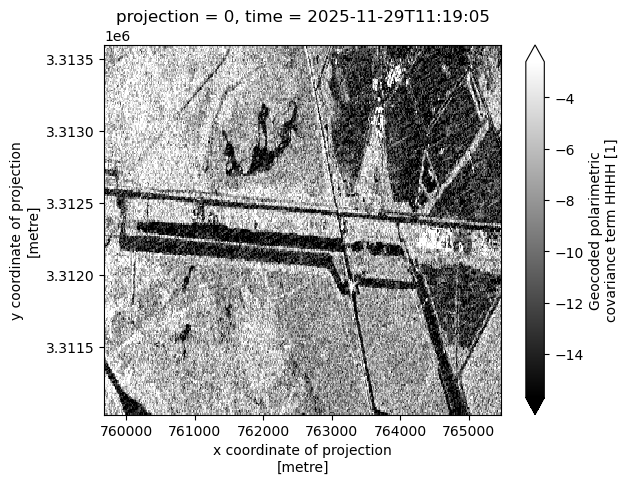

In [16]:
vmin = ts.isel(time=0).quantile(0.05, skipna=True).values.item()
vmax = ts.isel(time=0).quantile(0.95, skipna=True).values.item()

if product_type == "SME2":
    cmap = "YlGnBu"
else:
    cmap = "gray"   

ts.isel(time=0).plot(vmin=vmin, vmax=vmax, cmap=cmap)

<hr>

(asf_search_stream-close)=
## 6. Close open files

Close all open files to prevent memory leaks.

### 6a. Close the files

In [17]:
for f in files:
    f.close()

<hr>

(asf_search_stream-summary)=
## 7. Summary
You now have the tools and knowledge that you need to search with `asf_search`, generate temporary S3 bucket credentials from an Earthdata Login Bearer Token, stream data with HTTPS requests or directly from S3 with `s3fs`, and load them into `xarray` data structures.

<hr>

(asf_search_stream-resources)=
## 8. Resources and references
 - [asf_search](https://github.com/asfadmin/Discovery-asf_search)
 - [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/aws-s3-access/)
 
**Author:** Alex Lewandowski